# ITNPAI2 Assignment
## Student ID: 3019061

In [7]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [8]:
# Import the libraries needed for saving files, timestamps, tables, and plots

import copy
import time
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import os
import random
from pathlib import Path
from collections import Counter
from datetime import datetime
import shutil
from google.colab import files

import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights

# Import evaluation metrics from scikit-learn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

from skimage.color import rgb2hsv, rgb2gray
from skimage.feature import hog

from sklearn.ensemble import RandomForestClassifier

import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

## Shared setup
This section sets the random seed, chooses the dataset location depending on whether the notebook is running in Colab or locally, builds a dataframe of image paths and labels, and creates the train/validation/test split used by all models.

In [9]:
# Set a fixed random seed so data splits and model results are reproducible.
# This makes it easier to compare models fairly across different runs.
# =========================
# 1. SHARED SETUP
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

colab = True   # True if using Google Colab
linked = True  # True if your Colab Drive has the Colab Notebooks/Assignment folder

if colab:
    from google.colab import drive
    drive.mount('/content/gdrive')

    filepath = '/content/gdrive/My Drive/'
    if linked:
        filepath = os.path.join(filepath, 'Colab Notebooks/Assignment/flower_photos')
    else:
        filepath = os.path.join(filepath, 'flower_photos')
else:
    # LOCAL WINDOWS PATH
    filepath = r"C:\Users\kevin\Desktop\Masters\Computer Vision\Assignment\flower_photos"

print("Reading data from", filepath)

# Create a unique results folder for this run.
# Storing results with a timestamp avoids overwriting previous experiments.
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RESULTS_DIR = Path(f"results_{timestamp}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

models_dir = "/content/saved_models"
results_dir = str(RESULTS_DIR)
os.makedirs(models_dir, exist_ok=True)

DATASET_DIR = Path(filepath)
IMG_EXTS = {".jpg"}


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def build_dataframe(class_root: Path):
    rows = []

    if not class_root.exists():
      raise FileNotFoundError(f"Dataset folder not found: {class_root}")

    class_dirs = sorted([d for d in class_root.iterdir() if d.is_dir()])

    if not class_dirs:
        raise ValueError(f"No class folders found in: {class_root}")

    for class_dir in class_dirs:
        for img_path in class_dir.rglob("*"):
            if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
                rows.append({
                    "filepath": str(img_path),
                    "label": class_dir.name
                })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No images found in: {class_root}")

    return df


set_seed(SEED)

df = build_dataframe(DATASET_DIR)

print("\nDataset root:", DATASET_DIR)
print(df.head())

print("\nClass counts:")
print(df["label"].value_counts())

# Train / validation / test split: 70 / 15 / 15
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

print("\nTrain class distribution:")
print(train_df["label"].value_counts())

Mounted at /content/gdrive
Reading data from /content/gdrive/My Drive/Colab Notebooks/Assignment/flower_photos

Dataset root: /content/gdrive/My Drive/Colab Notebooks/Assignment/flower_photos
                                            filepath  label
0  /content/gdrive/My Drive/Colab Notebooks/Assig...  daisy
1  /content/gdrive/My Drive/Colab Notebooks/Assig...  daisy
2  /content/gdrive/My Drive/Colab Notebooks/Assig...  daisy
3  /content/gdrive/My Drive/Colab Notebooks/Assig...  daisy
4  /content/gdrive/My Drive/Colab Notebooks/Assig...  daisy

Class counts:
label
dandelion     898
tulips        799
sunflowers    699
roses         641
daisy         633
Name: count, dtype: int64

Split sizes:
Train: 2569
Val:   550
Test:  551

Train class distribution:
label
dandelion     629
tulips        559
sunflowers    489
roses         449
daisy         443
Name: count, dtype: int64


## Classical feature extraction baseline
These helper functions resize each image, extract handcrafted colour and edge features, and convert the image set into a feature matrix that can be used by scikit-learn models.

In [10]:
# Define the target image size used for the handcrafted baseline.
# Every image is resized to a consistent resolution before feature extraction.
# =========================
# 2. CLASSICAL BASELINE
# =========================

IMG_SIZE = (224, 224)


def load_rgb_image(path, size=IMG_SIZE):
     # Open the image, force RGB so every sample has three channels,
    # and resize it to the fixed resolution used by the classical models.
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.array(img)


def colour_hist_features(img_rgb, bins=16):
    """
    HSV colour histogram features.
    """
    hsv = rgb2hsv(img_rgb)
    feats = []
    for ch in range(3):
        hist, _ = np.histogram(hsv[:, :, ch], bins=bins, range=(0, 1), density=True)
        feats.extend(hist)
    return np.array(feats, dtype=np.float32)


def hog_features(img_rgb):
    """
    HOG = gradient/edge descriptor.
    """
    gray = rgb2gray(img_rgb)
    feats = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )
    return feats.astype(np.float32)


def extract_features(path):
    # Combine colour and gradient descriptors into one feature vector.
    img = load_rgb_image(path)
    hist = colour_hist_features(img, bins=16)
    hog_feat = hog_features(img)
    return np.concatenate([hist, hog_feat]).astype(np.float32)


def make_feature_matrix(dataframe):
    # Loop through the dataframe and build the design matrix X and label vector y.
    X = []
    y = []
    for _, row in dataframe.iterrows():
        X.append(extract_features(row["filepath"]))
        y.append(row["label"])
    return np.array(X), np.array(y)

## Classical models: Random Forest and SVM
The next cells train two classical machine-learning baselines on the handcrafted features, evaluate them, and save the fitted models for later use in the desktop application.

In [11]:
# Convert the train, validation, and test image sets into numeric feature matrices.
# These matrices are then used by the Random Forest and SVM classifiers.
# =========================
# CLASSICAL MODELS
# Random Forest + SVM
# =========================
print("Extracting train features...")
X_train, y_train = make_feature_matrix(train_df)
print("Train feature matrix shape:", X_train.shape)

print("Extracting val features...")
X_val, y_val = make_feature_matrix(val_df)
print("Validation feature matrix shape:", X_val.shape)

print("Extracting test features...")
X_test, y_test = make_feature_matrix(test_df)
print("Test feature matrix shape:", X_train.shape)

Extracting train features...
Train feature matrix shape: (2569, 6132)
Extracting val features...
Validation feature matrix shape: (550, 6132)
Extracting test features...
Test feature matrix shape: (2569, 6132)


In [12]:
# Train a Random Forest on the handcrafted features.
# This model acts as a strong classical baseline for comparison with MobileNetV2.
# -------------------------
# 1. RANDOM FOREST
# -------------------------
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)

val_preds_rf = rf.predict(X_val)
test_preds_rf = rf.predict(X_test)

print("\n=== RANDOM FOREST: Validation Results ===")
print("Accuracy:", accuracy_score(y_val, val_preds_rf))
print("Macro F1:", f1_score(y_val, val_preds_rf, average="macro"))
print(classification_report(y_val, val_preds_rf, zero_division=0))

print("\n=== RANDOM FOREST: Test Results ===")
print("Accuracy:", accuracy_score(y_test, test_preds_rf))
print("Macro F1:", f1_score(y_test, test_preds_rf, average="macro"))
print(classification_report(y_test, test_preds_rf, zero_division=0))

joblib.dump(rf, os.path.join(models_dir, "flower_random_forest.pkl"))


=== RANDOM FOREST: Validation Results ===
Accuracy: 0.5418181818181819
Macro F1: 0.5240373010503042
              precision    recall  f1-score   support

       daisy       0.60      0.33      0.42        95
   dandelion       0.49      0.70      0.58       134
       roses       0.62      0.41      0.49        96
  sunflowers       0.47      0.50      0.48       105
      tulips       0.61      0.68      0.65       120

    accuracy                           0.54       550
   macro avg       0.56      0.52      0.52       550
weighted avg       0.55      0.54      0.53       550


=== RANDOM FOREST: Test Results ===
Accuracy: 0.515426497277677
Macro F1: 0.49687003802573726
              precision    recall  f1-score   support

       daisy       0.66      0.33      0.44        95
   dandelion       0.49      0.73      0.59       135
       roses       0.49      0.35      0.41        96
  sunflowers       0.51      0.52      0.52       105
      tulips       0.52      0.55      0.54 

['/content/saved_models/flower_random_forest.pkl']

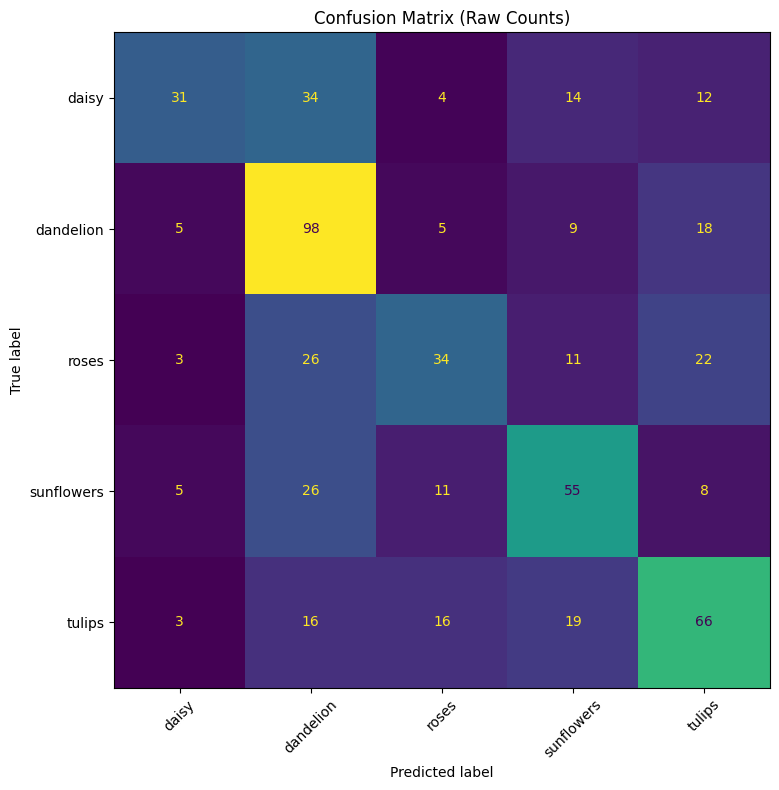

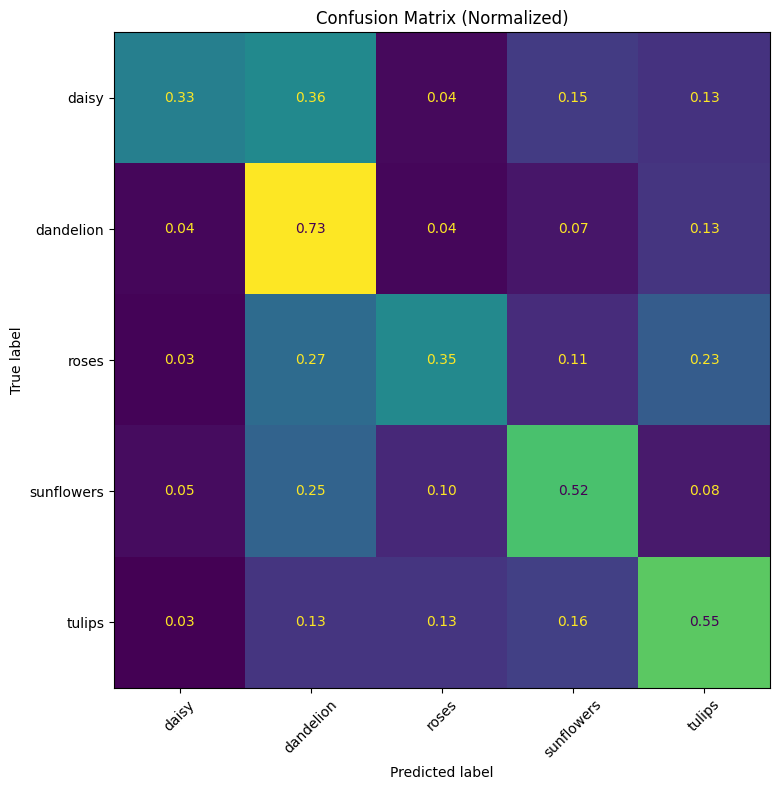

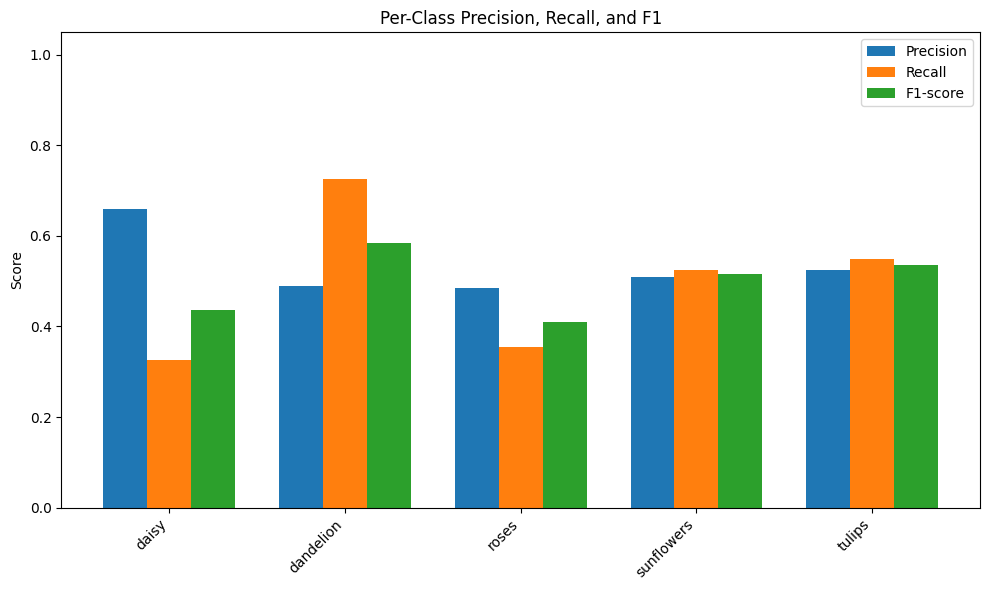

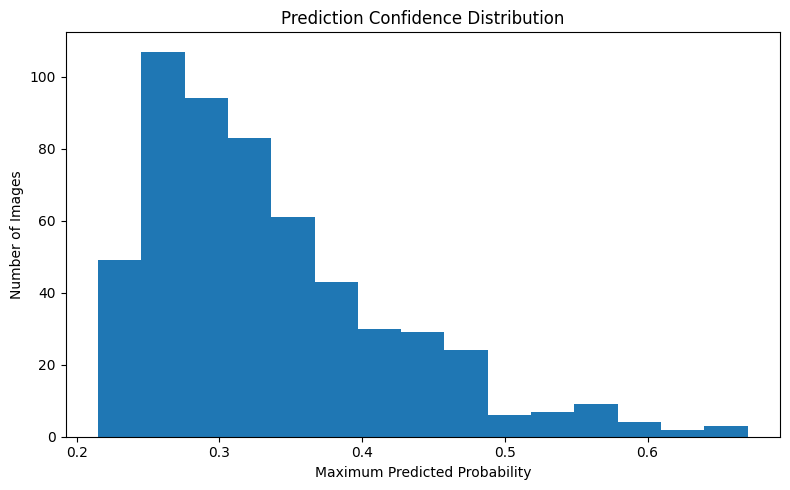

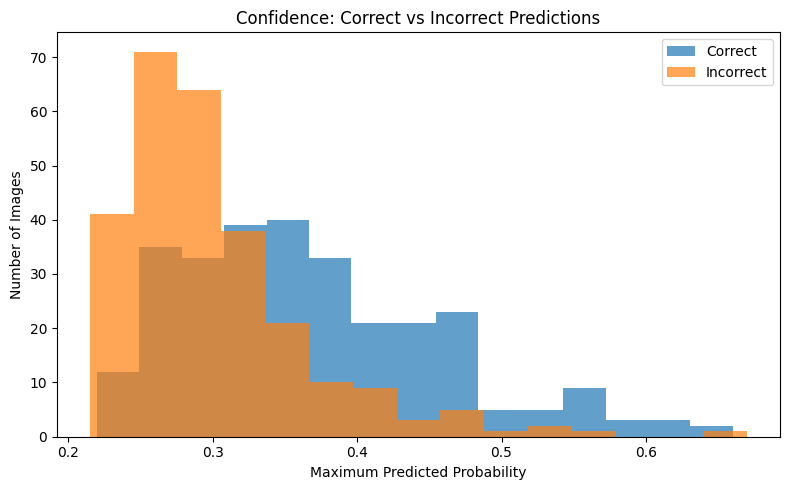

In [13]:
# Plot evaluation graphs for the Random Forest.
# The class order is taken directly from the fitted model so labels match the confusion matrix correctly.
# -----------------------------
# 1. RAW CONFUSION MATRIX
# -----------------------------
# Use the classes learned by the Random Forest
model_classes = list(rf.classes_)

cm = confusion_matrix(y_test, test_preds_rf, labels=model_classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Confusion Matrix (Raw Counts)")
plt.tight_layout()
plt.show()

# -----------------------------
# 2. NORMALIZED CONFUSION MATRIX
# -----------------------------
cm_norm = confusion_matrix(y_test, test_preds_rf, labels=model_classes, normalize="true")

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=model_classes)
disp.plot(ax=ax, xticks_rotation=45, values_format=".2f", colorbar=False)
ax.set_title("Confusion Matrix (Normalized)")
plt.tight_layout()
plt.show()

# -----------------------------
# 3. PER-CLASS METRICS
# -----------------------------
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    test_preds_rf,
    labels=model_classes,
    zero_division=0
)

metrics_df = pd.DataFrame({
    "class": model_classes,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

x = np.arange(len(model_classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, metrics_df["precision"], width, label="Precision")
ax.bar(x, metrics_df["recall"], width, label="Recall")
ax.bar(x + width, metrics_df["f1"], width, label="F1-score")

ax.set_xticks(x)
ax.set_xticklabels(model_classes, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision, Recall, and F1")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4. CONFIDENCE HISTOGRAM
# -----------------------------
test_probs_rf = rf.predict_proba(X_test)
max_probs = np.max(test_probs_rf, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(max_probs, bins=15)
ax.set_xlabel("Maximum Predicted Probability")
ax.set_ylabel("Number of Images")
ax.set_title("Prediction Confidence Distribution")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. CORRECT VS INCORRECT CONFIDENCE
# -----------------------------
correct_mask = (test_preds_rf == y_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(max_probs[correct_mask], bins=15, alpha=0.7, label="Correct")
ax.hist(max_probs[~correct_mask], bins=15, alpha=0.7, label="Incorrect")
ax.set_xlabel("Maximum Predicted Probability")
ax.set_ylabel("Number of Images")
ax.set_title("Confidence: Correct vs Incorrect Predictions")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Train an SVM on the same handcrafted features.
# StandardScaler is included in the pipeline because SVMs work best when features are on a similar scale.
# -------------------------
# 2. SVM
# -------------------------
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",         # good strong default
        C=10,
        gamma="scale",
        probability=True,     # needed for confidence plots / ROC curves
        class_weight="balanced",
        random_state=SEED
    ))
])

svm_model.fit(X_train, y_train)

val_preds_svm = svm_model.predict(X_val)
test_preds_svm = svm_model.predict(X_test)

print("\n=== SVM: Validation Results ===")
print("Accuracy:", accuracy_score(y_val, val_preds_svm))
print("Macro F1:", f1_score(y_val, val_preds_svm, average="macro"))
print(classification_report(y_val, val_preds_svm, zero_division=0))

print("\n=== SVM: Test Results ===")
print("Accuracy:", accuracy_score(y_test, test_preds_svm))
print("Macro F1:", f1_score(y_test, test_preds_svm, average="macro"))
print(classification_report(y_test, test_preds_svm, zero_division=0))

joblib.dump(svm_model, os.path.join(models_dir, "flower_svm.pkl"))


=== SVM: Validation Results ===
Accuracy: 0.5327272727272727
Macro F1: 0.5258631605437551
              precision    recall  f1-score   support

       daisy       0.50      0.42      0.46        95
   dandelion       0.58      0.55      0.56       134
       roses       0.49      0.51      0.50        96
  sunflowers       0.48      0.52      0.50       105
      tulips       0.59      0.62      0.61       120

    accuracy                           0.53       550
   macro avg       0.53      0.53      0.53       550
weighted avg       0.53      0.53      0.53       550


=== SVM: Test Results ===
Accuracy: 0.5372050816696915
Macro F1: 0.5285697095118479
              precision    recall  f1-score   support

       daisy       0.53      0.43      0.48        95
   dandelion       0.61      0.64      0.62       135
       roses       0.46      0.48      0.47        96
  sunflowers       0.49      0.55      0.52       105
      tulips       0.57      0.54      0.55       120

    accur

['/content/saved_models/flower_svm.pkl']

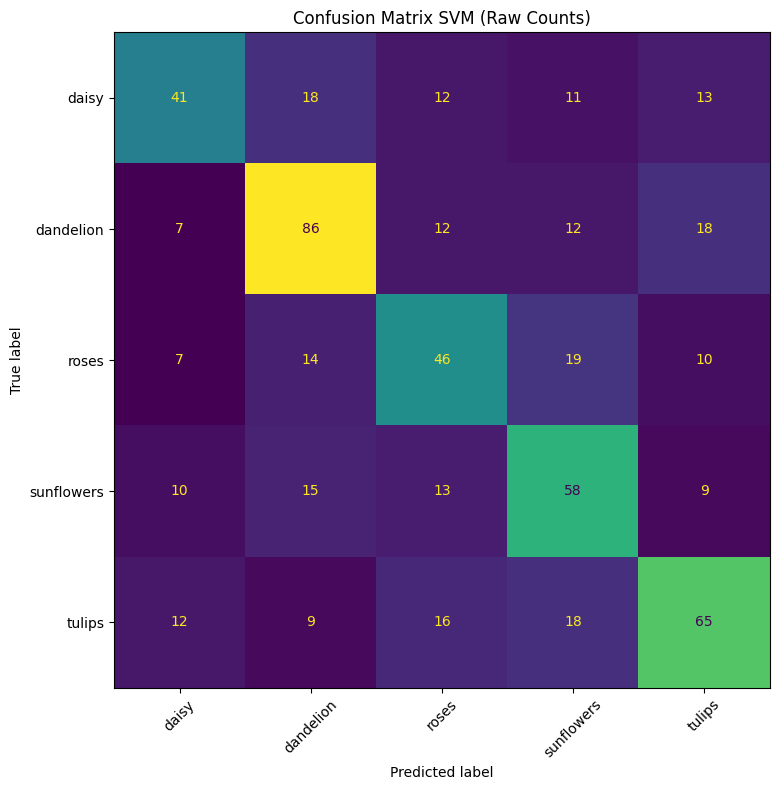

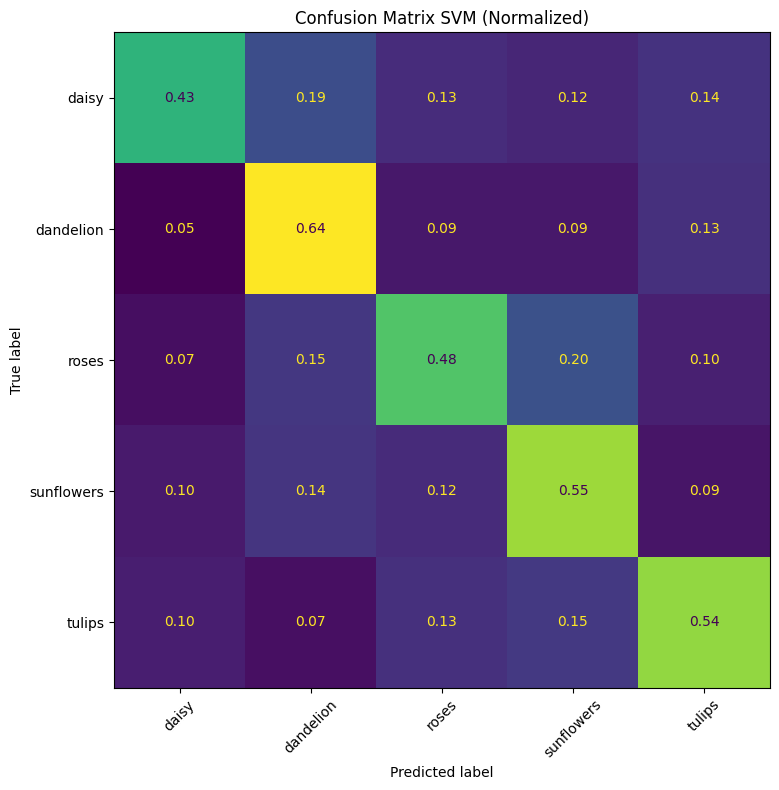

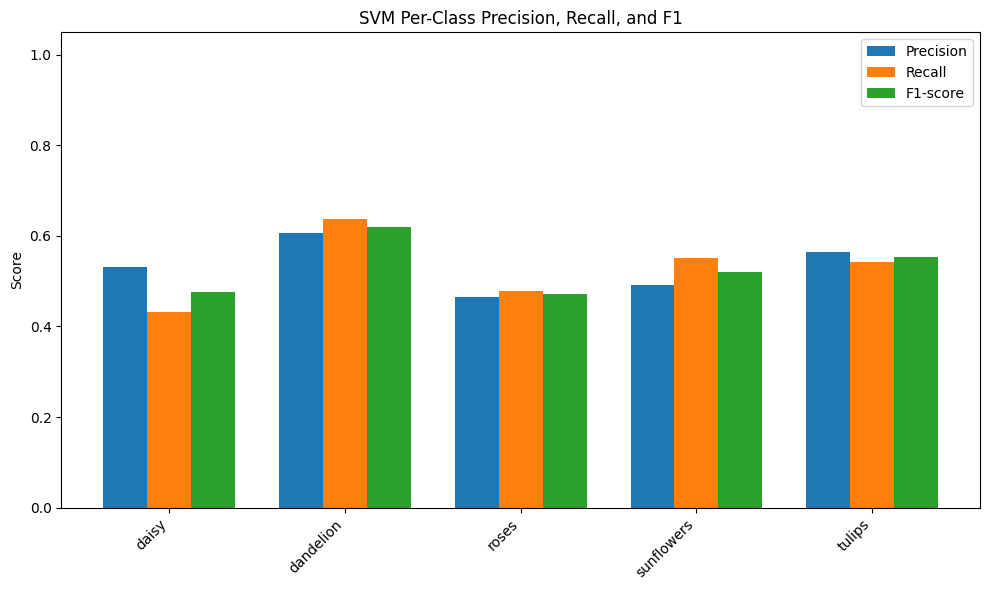

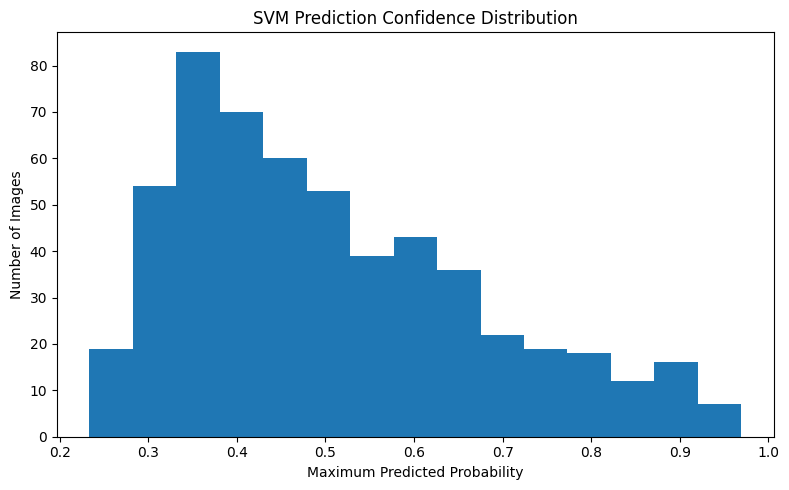

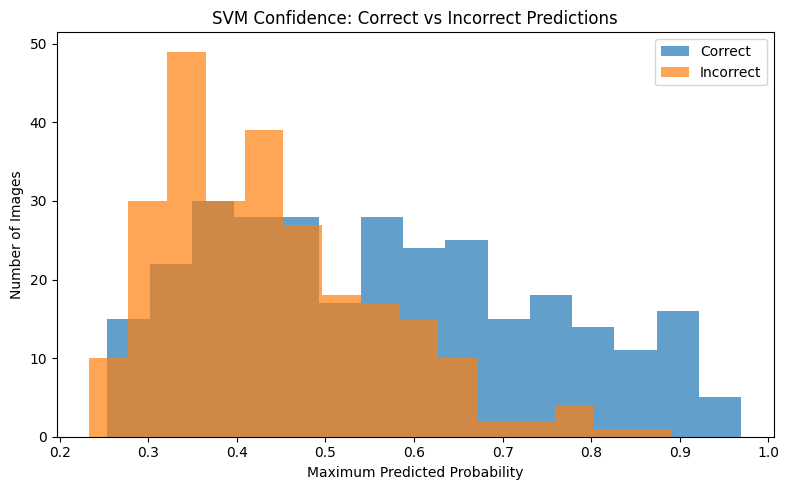

In [16]:
# Plot evaluation graphs for the SVM model.
# These figures help show where the model performs well and which flower classes are often confused.
# Get the class labels from the SVM model.
# Because svm_model is a Pipeline, we read the classes from the final SVM step.
svm_classes = list(svm_model.named_steps["svm"].classes_)

# Get predicted class labels for the test set.
test_preds_svm = svm_model.predict(X_test)

# Get predicted probabilities for the test set.
# This only works if SVC was trained with probability=True.
test_probs_svm = svm_model.predict_proba(X_test)

# Get the highest probability for each prediction.
max_probs_svm = np.max(test_probs_svm, axis=1)

# -----------------------------
# 1. RAW CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_test, test_preds_svm, labels=svm_classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Confusion Matrix SVM (Raw Counts)")
plt.tight_layout()
plt.show()


# -----------------------------
# 2. NORMALIZED CONFUSION MATRIX
# -----------------------------
cm_norm = confusion_matrix(
    y_test,
    test_preds_svm,
    labels=svm_classes,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=svm_classes)
disp.plot(ax=ax, xticks_rotation=45, values_format=".2f", colorbar=False)
ax.set_title("Confusion Matrix SVM (Normalized)")
plt.tight_layout()
plt.show()

# -----------------------------
# 3. PER-CLASS METRICS
# -----------------------------
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    test_preds_svm,
    labels=svm_classes,
    zero_division=0
)

metrics_df = pd.DataFrame({
    "class": svm_classes,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

x = np.arange(len(svm_classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, metrics_df["precision"], width, label="Precision")
ax.bar(x, metrics_df["recall"], width, label="Recall")
ax.bar(x + width, metrics_df["f1"], width, label="F1-score")

ax.set_xticks(x)
ax.set_xticklabels(svm_classes, rotation=45, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("SVM Per-Class Precision, Recall, and F1")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4. CONFIDENCE HISTOGRAM
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(max_probs_svm, bins=15)
ax.set_xlabel("Maximum Predicted Probability")
ax.set_ylabel("Number of Images")
ax.set_title("SVM Prediction Confidence Distribution")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. CORRECT VS INCORRECT CONFIDENCE
# -----------------------------
correct_mask = (test_preds_svm == y_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(max_probs_svm[correct_mask], bins=15, alpha=0.7, label="Correct")
ax.hist(max_probs_svm[~correct_mask], bins=15, alpha=0.7, label="Incorrect")
ax.set_xlabel("Maximum Predicted Probability")
ax.set_ylabel("Number of Images")
ax.set_title("SVM Confidence: Correct vs Incorrect Predictions")
ax.legend()
plt.tight_layout()
plt.show()

# MOBILENETV2

## MobileNetV2 transfer-learning model
This section defines a PyTorch dataset, creates data loaders, builds a pretrained MobileNetV2 model, fine-tunes it on the flower dataset, and evaluates it on the held-out test set.

In [17]:
# Choose GPU if one is available, otherwise fall back to CPU.
# The label dictionaries are used to convert between class names and numeric indices.
# =========================
# 3. MOBILENETV2
# =========================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

class_names = sorted(df["label"].unique())
label_to_idx = {label: i for i, label in enumerate(class_names)}
idx_to_label = {i: label for label, i in label_to_idx.items()}


class FlowerDataset(Dataset):
    def __init__(self, dataframe, label_to_idx, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Read one image/label pair and apply the requested transform.
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        label = self.label_to_idx[row["label"]]

        if self.transform is not None:
            img = self.transform(img)

        return img, label


weights = MobileNet_V2_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = FlowerDataset(train_df, label_to_idx, transform=train_transform)
val_dataset = FlowerDataset(val_df, label_to_idx, transform=eval_transform)
test_dataset = FlowerDataset(test_df, label_to_idx, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Build MobileNetV2
model = models.mobilenet_v2(weights=weights)

# Replace the final classifier layer
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(class_names))

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

def run_epoch(model, loader, criterion, optimizer=None):
    # If an optimizer is supplied we are training, otherwise we are only evaluating.
    training = optimizer is not None
    model.train() if training else model.eval()

    running_loss = 0.0
    preds_all = []
    labels_all = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, dim=1)

            if training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(labels_all, preds_all)
    epoch_f1 = f1_score(labels_all, preds_all, average="macro")

    return epoch_loss, epoch_acc, epoch_f1

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 207MB/s]


In [18]:
# Fine-tune MobileNetV2 and keep the weights from the best validation epoch.
# Early stopping is used so training stops once validation performance stops improving.
best_model_wts = copy.deepcopy(model.state_dict())
best_val_f1 = -1.0
patience = 5
patience_counter = 0
num_epochs = 12

for epoch in range(num_epochs):
    start = time.time()

    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    elapsed = time.time() - start
    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_wts)
print("Best validation macro F1:", best_val_f1)

Epoch 01/12 | Train Loss: 0.4842 Acc: 0.8381 F1: 0.8353 | Val Loss: 0.5021 Acc: 0.8382 F1: 0.8310 | Time: 41.1s
Epoch 02/12 | Train Loss: 0.3052 Acc: 0.9007 F1: 0.9000 | Val Loss: 0.3194 Acc: 0.8764 F1: 0.8752 | Time: 35.0s
Epoch 03/12 | Train Loss: 0.2213 Acc: 0.9229 F1: 0.9220 | Val Loss: 0.3101 Acc: 0.8927 F1: 0.8925 | Time: 35.0s
Epoch 04/12 | Train Loss: 0.2046 Acc: 0.9334 F1: 0.9328 | Val Loss: 0.3501 Acc: 0.8873 F1: 0.8858 | Time: 34.9s
Epoch 05/12 | Train Loss: 0.2043 Acc: 0.9342 F1: 0.9337 | Val Loss: 0.3722 Acc: 0.8800 F1: 0.8804 | Time: 34.1s
Epoch 06/12 | Train Loss: 0.1456 Acc: 0.9545 F1: 0.9539 | Val Loss: 0.3631 Acc: 0.8982 F1: 0.8965 | Time: 37.0s
Epoch 07/12 | Train Loss: 0.1217 Acc: 0.9580 F1: 0.9570 | Val Loss: 0.2842 Acc: 0.9218 F1: 0.9215 | Time: 36.3s
Epoch 08/12 | Train Loss: 0.1665 Acc: 0.9443 F1: 0.9431 | Val Loss: 0.3221 Acc: 0.9073 F1: 0.9062 | Time: 38.0s
Epoch 09/12 | Train Loss: 0.1993 Acc: 0.9366 F1: 0.9360 | Val Loss: 0.3662 Acc: 0.8873 F1: 0.8851 | Time

In [19]:
# Evaluate the best MobileNetV2 model on the held-out test set.
# This gives the final accuracy, macro F1 score, and confusion matrix used in the report.
# Final test evaluation
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("\n=== MobileNetV2 Test Results ===")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Macro F1:", f1_score(all_labels, all_preds, average="macro"))

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)


=== MobileNetV2 Test Results ===
Accuracy: 0.9401088929219601
Macro F1: 0.9381990111001592
              precision    recall  f1-score   support

       daisy       0.98      0.91      0.94        95
   dandelion       0.98      0.98      0.98       135
       roses       0.89      0.90      0.89        96
  sunflowers       0.96      1.00      0.98       105
      tulips       0.89      0.91      0.90       120

    accuracy                           0.94       551
   macro avg       0.94      0.94      0.94       551
weighted avg       0.94      0.94      0.94       551

Confusion matrix:
 [[ 86   3   2   1   3]
 [  0 132   0   0   3]
 [  0   0  86   3   7]
 [  0   0   0 105   0]
 [  2   0   9   0 109]]


In [20]:
# Save the trained MobileNetV2 weights and class mapping.
# This checkpoint is later loaded by the desktop application for image upload prediction.
# Save MobileNetV2
checkpoint = {
    "model_name": "mobilenet_v2",
    "num_classes": len(class_names),
    "class_names": class_names,
    "label_to_idx": label_to_idx,
    "model_state_dict": model.state_dict()
}
torch.save(checkpoint, os.path.join(models_dir, "flower_mobilenetv2.pth"))

In [24]:
# Build a small results table comparing the baseline models with MobileNetV2.
results = pd.DataFrame({
    "Model": [
        "Colour Histogram + HOG + Random Forest",
        "Colour Histogram + HOG + SVM (RBF kernel)",
        "MobileNetV2"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, test_preds_rf),
        accuracy_score(y_test, test_preds_svm),
        accuracy_score(all_labels, all_preds)
    ],
    "Test Macro F1": [
        f1_score(y_test, test_preds_rf, average="macro"),
        f1_score(y_test, test_preds_svm, average="macro"),
        f1_score(all_labels, all_preds, average="macro")
    ]
})

print(results)

                                       Model  Test Accuracy  Test Macro F1
0     Colour Histogram + HOG + Random Forest       0.515426       0.496870
1  Colour Histogram + HOG + SVM (RBF kernel)       0.537205       0.528570
2                                MobileNetV2       0.940109       0.938199


## Saving results and model outputs
The final section stores metrics, confusion matrices, per-image predictions, and summary tables so the experiment can be reproduced and compared later.

In [25]:
# Helper functions for saving scikit-learn model results.
# These functions export metrics, reports, confusion matrices, and per-image predictions to disk.
def get_model_classes(model):
    """
    Returns class labels from either:
    - a plain sklearn model
    - a Pipeline containing a final classifier
    """
    if hasattr(model, "classes_"):
        return list(model.classes_)
    elif hasattr(model, "named_steps"):
        final_step = list(model.named_steps.values())[-1]
        return list(final_step.classes_)
    else:
        raise ValueError("Could not find classes_ on this model.")


def save_sklearn_results(model, model_name, X_test, y_test, test_df, results_dir):
    """
    Saves:
    - metrics JSON
    - classification report CSV
    - confusion matrix CSV
    - confusion matrix PNG
    - per-image predictions CSV
    """
    model_classes = get_model_classes(model)

    preds = model.predict(X_test)

    # Some models have predict_proba, some do not
    probs = None
    max_probs = [None] * len(preds)
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)
        max_probs = np.max(probs, axis=1)

    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro")

    report_dict = classification_report(
        y_test,
        preds,
        labels=model_classes,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(y_test, preds, labels=model_classes)

    # -------------------------
    # Save metrics JSON
    # -------------------------
    metrics = {
        "model_name": model_name,
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "classes": model_classes
    }

    with open(results_dir / f"{model_name}_metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

    # -------------------------
    # Save classification report
    # -------------------------
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(results_dir / f"{model_name}_classification_report.csv")

    # -------------------------
    # Save confusion matrix CSV
    # -------------------------
    cm_df = pd.DataFrame(cm, index=model_classes, columns=model_classes)
    cm_df.to_csv(results_dir / f"{model_name}_confusion_matrix.csv")

    # -------------------------
    # Save confusion matrix PNG
    # -------------------------
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_classes)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(results_dir / f"{model_name}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    # -------------------------
    # Save per-image predictions
    # -------------------------
    pred_df = test_df.reset_index(drop=True).copy()
    pred_df["true_label"] = y_test
    pred_df["predicted_label"] = preds
    pred_df["correct"] = pred_df["true_label"] == pred_df["predicted_label"]
    pred_df["confidence"] = max_probs
    pred_df.to_csv(results_dir / f"{model_name}_predictions.csv", index=False)

    print(f"Saved {model_name} results.")

In [26]:
# Equivalent helper function for the MobileNetV2 model.
# It saves both overall metrics and detailed per-image predictions for future reference.
def save_torch_results(model, model_name, test_loader, class_names, test_df, results_dir, device):
    """
    Saves:
    - metrics JSON
    - classification report CSV
    - confusion matrix CSV
    - confusion matrix PNG
    - per-image predictions CSV
    """
    model.eval()

    all_preds = []
    all_labels = []
    all_confidences = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(torch.max(probs, dim=1).values.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_confidences = np.array(all_confidences)

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    label_indices = list(range(len(class_names)))

    report_dict = classification_report(
        all_labels,
        all_preds,
        labels=label_indices,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds, labels=label_indices)

    # -------------------------
    # Save metrics JSON
    # -------------------------
    metrics = {
        "model_name": model_name,
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "classes": class_names
    }

    with open(results_dir / f"{model_name}_metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

    # -------------------------
    # Save classification report
    # -------------------------
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(results_dir / f"{model_name}_classification_report.csv")

    # -------------------------
    # Save confusion matrix CSV
    # -------------------------
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.to_csv(results_dir / f"{model_name}_confusion_matrix.csv")

    # -------------------------
    # Save confusion matrix PNG
    # -------------------------
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(results_dir / f"{model_name}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    # -------------------------
    # Save per-image predictions
    # -------------------------
    pred_df = test_df.reset_index(drop=True).copy()
    pred_df["true_label_idx"] = all_labels
    pred_df["predicted_label_idx"] = all_preds
    pred_df["true_label"] = [class_names[i] for i in all_labels]
    pred_df["predicted_label"] = [class_names[i] for i in all_preds]
    pred_df["correct"] = pred_df["true_label"] == pred_df["predicted_label"]
    pred_df["confidence"] = all_confidences
    pred_df.to_csv(results_dir / f"{model_name}_predictions.csv", index=False)

    print(f"Saved {model_name} results.")

In [27]:
# Save the Random Forest outputs to the results folder.
save_sklearn_results(
    model=rf,
    model_name="random_forest",
    X_test=X_test,
    y_test=y_test,
    test_df=test_df,
    results_dir=RESULTS_DIR
)

Saved random_forest results.


In [28]:
# Save the SVM outputs to the results folder.
save_sklearn_results(
    model=svm_model,
    model_name="svm",
    X_test=X_test,
    y_test=y_test,
    test_df=test_df,
    results_dir=RESULTS_DIR
)

Saved svm results.


In [29]:
# Save the MobileNetV2 outputs to the results folder.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

save_torch_results(
    model=model,
    model_name="mobilenetv2",
    test_loader=test_loader,
    class_names=class_names,
    test_df=test_df,
    results_dir=RESULTS_DIR,
    device=device
)

Saved mobilenetv2 results.


In [30]:
# Read back all saved metric files and create one summary table.
# This table is useful for quickly ranking the models by test performance.
summary_rows = []

for model_file in RESULTS_DIR.glob("*_metrics.json"):
    with open(model_file, "r") as f:
        metrics = json.load(f)
    summary_rows.append({
        "Model": metrics["model_name"],
        "Accuracy": metrics["accuracy"],
        "Macro F1": metrics["macro_f1"]
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Macro F1", ascending=False)
summary_df.to_csv(RESULTS_DIR / "model_summary.csv", index=False)

print(summary_df)

           Model  Accuracy  Macro F1
2    mobilenetv2  0.940109  0.938199
0            svm  0.537205  0.528570
1  random_forest  0.515426  0.496870


In [31]:
# Zip models
if os.path.exists(models_dir):
    models_zip = shutil.make_archive("/content/saved_models", "zip", models_dir)
    print("Created:", models_zip)
    files.download(models_zip)
else:
    print("Models folder not found:", models_dir)

# Zip results
if os.path.exists(results_dir):
    results_zip = shutil.make_archive("/content/results_backup", "zip", results_dir)
    print("Created:", results_zip)
    files.download(results_zip)
else:
    print("Results folder not found:", results_dir)

Created: /content/saved_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created: /content/results_backup.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>